# 03. Harmonisation and validation

Construct the canonical 1977-2025 B.9 panel, prove the subsector identity closes, quantify the 1995 vintage revision, and expose the four-year detailed-account gap instead of imputing it.

**Reads**

- `data/raw/banco_portugal/series_longas_2023-12.xlsx`
- `data/raw/pordata/pordata_2785_balance_by_level_1995_2025.csv`
- `data/raw/cfp/cfp_sec2010_annual_general_government_2026-04-15.xlsx`
- `data/raw/cfp/cfp_sec2010_annual_subsectors_2026-04-15.xlsx`

**Writes**

- Nothing. The pipeline persists the canonical panels; here they are validated.

**Method reference:** `METHODOLOGY.md` sections 2-4

In [1]:
"""Notebook environment: locate the repository and expose its data layers."""

import sys
import warnings
from pathlib import Path

import pandas as pd
from IPython.display import display

# Resolve the repository root from wherever the kernel was started, so the
# notebook works both from the repository root and from the notebooks directory.
ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

%matplotlib inline

from portugal_fiscal_balance.analysis import figures

RAW = ROOT / 'data' / 'raw'
INTERIM = ROOT / 'data' / 'interim'
PROCESSED = ROOT / 'data' / 'processed'
TABLES = ROOT / 'outputs' / 'tables'
METRICS = ROOT / 'outputs' / 'metrics'

warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)

print('repository:', ROOT.name)
print('pipeline outputs present:', (PROCESSED / 'fiscal_balances_1977_2025.csv').exists())

repository: portugal-fiscal-balance
pipeline outputs present: True


## 1. Build the canonical balance panel

The panel takes 1977-1994 from the historical long series and 1995-2025 from the
modern bridge, attaches modern nominal GDP, and refuses to build at all unless
every year from 1977 to 2025 is present exactly once.

In [2]:
from portugal_fiscal_balance.processing.harmonize import (
    build_methodology_overlap,
    harmonize_account_panel,
    harmonize_balance_panel,
)
from portugal_fiscal_balance.processing.validation import validate_accounts, validate_balance_panel
from portugal_fiscal_balance.sources.banco_portugal import extract_long_series
from portugal_fiscal_balance.sources.cfp import extract_cfp_annual
from portugal_fiscal_balance.sources.pordata import load_balance_snapshot

historical = extract_long_series(RAW / 'banco_portugal' / 'series_longas_2023-12.xlsx')
modern = load_balance_snapshot(RAW / 'pordata' / 'pordata_2785_balance_by_level_1995_2025.csv')
cfp = extract_cfp_annual(
    RAW / 'cfp' / 'cfp_sec2010_annual_general_government_2026-04-15.xlsx',
    RAW / 'cfp' / 'cfp_sec2010_annual_subsectors_2026-04-15.xlsx',
)
panel = harmonize_balance_panel(
    historical.balances,
    modern,
    cfp.general_government[['year', 'nominal_gdp_m_eur']],
)
print(validate_balance_panel(panel))
display(panel.groupby('statistical_regime')['year'].agg(['min', 'max', 'count']))

{'n_years': 49, 'max_abs_closure_error_m_eur': 1.0, 'all_closures_within_2m_eur': True}


,min,max,count
statistical_regime,,,
historical_long_series,1977,1994,18
modern_national_accounts,1995,2025,31


## 2. Does the identity close?

$$B^{GG}_t - \left(B^{C}_t + B^{RL}_t + B^{SSF}_t\right) = 0.$$

The residual is kept as a column rather than assumed away. Published national
accounts are rounded to the million, so a tolerance of 2 M EUR is applied and
every year must fall inside it.

In [3]:
print('max |closure residual| (M EUR):', round(float(panel['closure_error_m_eur'].abs().max()), 6))
print('years inside the 2 M EUR tolerance:', int(panel['closure_within_tolerance'].sum()), 'of', len(panel))
rounding_scale = panel.loc[panel['closure_error_m_eur'].abs().ge(0.5), ['year', 'closure_error_m_eur']]
print('years with a residual of 1 M EUR or more:', len(rounding_scale))
display(rounding_scale.round(3).set_index('year').T)

max |closure residual| (M EUR): 1.0
years inside the 2 M EUR tolerance: 49 of 49
years with a residual of 1 M EUR or more: 8


year,2004,2006,2012,2014,2017,2019,2021,2022
closure_error_m_eur,-1.0,1.0,1.0,-1.0,-1.0,1.0,1.0,1.0


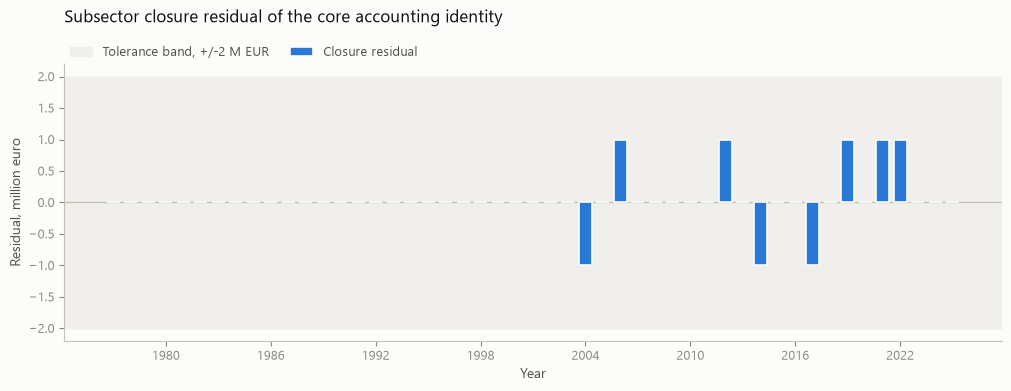

In [4]:
figure = figures.closure_errors(panel)

## 3. The 1995 splice, quantified

1995 exists in both sources. Rather than choose silently, the repository keeps
both vintages and reports the revision. The modern vintage is the one used in the
canonical panel.

In [5]:
overlap = build_methodology_overlap(historical.balances, modern)
display(overlap.round(1))

,metric,historical_1995_m_eur,modern_1995_m_eur,difference_m_eur
0,general_government_balance_m_eur,-4557.7,-4611.0,-53.3
1,central_government_balance_m_eur,-4220.7,-4235.0,-14.3
2,regional_local_balance_m_eur,32.6,66.0,33.4
3,social_security_balance_m_eur,-369.5,-442.0,-72.5


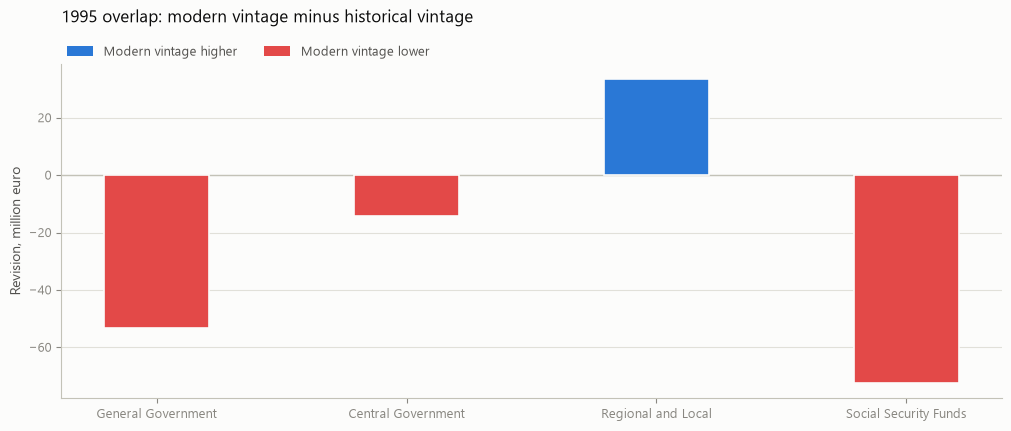

In [6]:
figure = figures.source_overlap_1995(overlap)

The revisions are small in level terms but non-zero for every subsector, which
is exactly why no analysis in this repository fits a model across 1995. Notebook
08 detects structural breaks inside each regime separately for the same reason.

## 4. The detailed account panel and its gap

General Government components run 1977-2025 continuously. The three subsectors
have components for 1977-1995 and 2000-2025 only. The intervening four years are
absent from the sources, so they are absent here.

In [7]:
accounts = harmonize_account_panel(historical.accounts, cfp.accounts)
display(accounts.groupby(['sector', 'statistical_regime'])['year'].agg(['min', 'max', 'count']))
subsectors = accounts.loc[accounts['sector'].ne('general_government')]
print('subsector observations in 1996-1999:', int(subsectors['year'].between(1996, 1999).sum()))

min   max  count
sector                    statistical_regime                       
central_government        esa2010_modern          2000  2025     26
                          historical_long_series  1977  1995     19
general_government        esa2010_modern          1995  2025     31
                          historical_long_series  1977  1994     18
regional_local_government esa2010_modern          2000  2025     26
                          historical_long_series  1977  1995     19
social_security_funds     esa2010_modern          2000  2025     26
                          historical_long_series  1977  1995     19

subsector observations in 1996-1999: 0


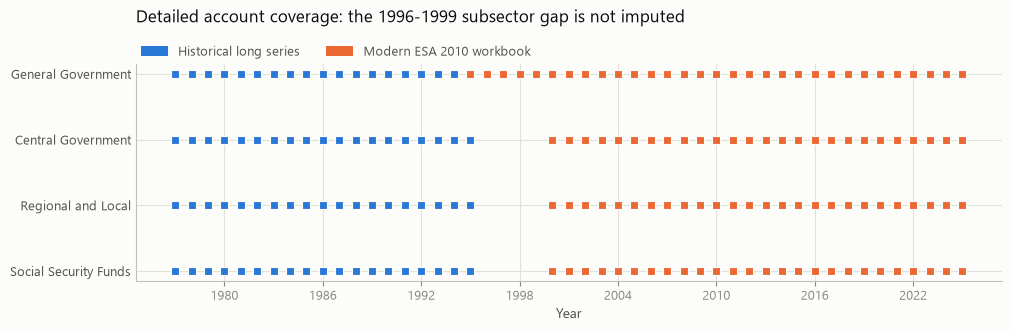

In [8]:
figure = figures.account_coverage(accounts)

## 5. Account identity check

For every sector-year with detailed components, revenue minus expenditure must
reproduce the recorded balance to numerical precision.

In [9]:
checks = validate_accounts(accounts)
worst = (
    checks.groupby('sector')['identity_error_m_eur']
    .apply(lambda column: column.abs().max())
    .rename('max_abs_identity_error_m_eur')
    .to_frame()
)
display(worst)
print('observations outside tolerance:', int((~checks['within_tolerance']).sum()))

,max_abs_identity_error_m_eur
sector,
central_government,5.456968e-12
general_government,1.136868e-12
regional_local_government,2.842171e-13
social_security_funds,9.379164e-13


observations outside tolerance: 0


## 6. Identity closure is not source agreement

These are two different tests and they are easy to conflate.

An **identity** check asks whether the extraction is arithmetically
self-consistent. It can close to numerical precision while both sources are wrong
in the same way, because it never consults a second source.

A **source-agreement** check asks whether two independently published sources
report the same number for the same year. Identity closure cannot establish it.

Both are collected below in one unit so they can be compared directly. The
identities close to rounding; the largest source disagreement is a Central
Government difference of roughly 67 M EUR in 2002.

In [10]:
from portugal_fiscal_balance.processing.validation import (
    compare_modern_balance_sources,
    source_validation_summary,
)
from portugal_fiscal_balance.analysis.debt import debt_reconciliation_table

comparison = compare_modern_balance_sources(modern, cfp.general_government, cfp.subsectors)
validation = source_validation_summary(
    balance_panel=panel,
    account_checks=checks,
    debt=debt_reconciliation_table(cfp.debt),
    source_comparison=comparison,
    overlap=overlap,
)
display(validation.round(3))

,check,comparison,n_observations,max_abs_difference_m_eur,year_of_max
0,Accounting identity,Aggregate balance minus the sum of its three s...,49,1.000,2004
1,Accounting identity,Revenue minus expenditure minus the recorded b...,184,0.000,"Central Government, 1994"
2,Accounting identity,Debt change against minus the balance plus the...,108,0.000,2000
3,Source agreement,"PORDATA bridge against the CFP workbook, Gener...",31,0.498,1995
4,Source agreement,"PORDATA bridge against the CFP workbook, Centr...",26,66.811,2002
5,Source agreement,"PORDATA bridge against the CFP workbook, Regio...",26,0.492,2002
6,Source agreement,"PORDATA bridge against the CFP workbook, Socia...",26,0.470,2019
7,Vintage revision,1995 modern vintage against the historical vin...,4,72.465,1995


## 7. Which years are still provisional?

The publisher flags its most recent years as provisional and the canonical panel
carries that flag through. These are also the years the report discusses in most
detail, so the flag matters.

In [11]:
display(panel.groupby('vintage_status')['year'].agg(['min', 'max', 'count']))
print(
    'provisional years:',
    panel.loc[panel['vintage_status'].eq('provisional'), 'year'].tolist(),
)

,min,max,count
vintage_status,,,
final,1977,2023,47
provisional,2024,2025,2


provisional years: [2024, 2025]


## Interpretation limits

1. **Nothing is smoothed, calibrated or chained across 1995.** The panel is a
   documented splice, not a homogeneous series.
2. **1996-1999 subsector components are missing, not zero.** Any statistic that
   needs them is computed on the years that exist. The canonical B.9 panel is
   complete and is unaffected.
3. **Closure within 2 M EUR is a rounding tolerance**, not a claim that the
   sources are internally consistent to the euro.
4. **Identity closure does not imply source agreement.** Section 6 reports both,
   and neither substitutes for the other.
5. **The most recent years are provisional** and will be revised by a later
   vintage.
6. Passing these checks establishes that the extraction is faithful. It says
   nothing about whether the underlying statistics are correct.

---

[Previous: 02. Modern extraction: INE/PORDATA and CFP](02_extract_modern_data.ipynb) | [Next: 04. Long-run balance decomposition](04_balance_decomposition.ipynb)

Every table shown above is also persisted as CSV, so results can be checked without reading notebook state. To rebuild everything from the bundled raw sources:

```bash
poetry install
make all
```